# Lesson 3B: DBSCAN Practical Applications

## Introduction

You understand DBSCAN theory. Now apply it to real data and learn the most critical skill: **choosing ε and minpts**.

Key skills:
- K-distance graphs for epsilon selection
- Real data case studies
- HDBSCAN: the parameter-robust alternative
- When DBSCAN outperforms K-Means and Hierarchical

In this lesson:
1. Master epsilon selection with k-distance plots
2. Apply DBSCAN to real clustering problems
3. Introduce HDBSCAN for automatic parameter selection
4. Compare three paradigms on the same dataset
5. Understand scalability and deployment trade-offs

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [K-Distance Graphs](#kdist)
4. [Epsilon Selection](#epsilon)
5. [Real Case Study](#casestudy)
6. [HDBSCAN: Hierarchical DBSCAN](#hdbscan)
7. [Comparison: All Three Paradigms](#comparison)
8. [When to Use Each](#when)
9. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, cdist
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import load_iris, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


<a name="kdist"></a>
## K-Distance Graphs: The Gold Standard for Epsilon Selection

### The Concept

The **k-distance graph** plots the distance from each point to its kth nearest neighbor (where k = minpts). The "elbow" point is a good candidate for ε.

**Why?** 
- Points in dense regions have small k-distances
- Points in sparse regions have large k-distances
- The elbow marks the transition → good ε choice

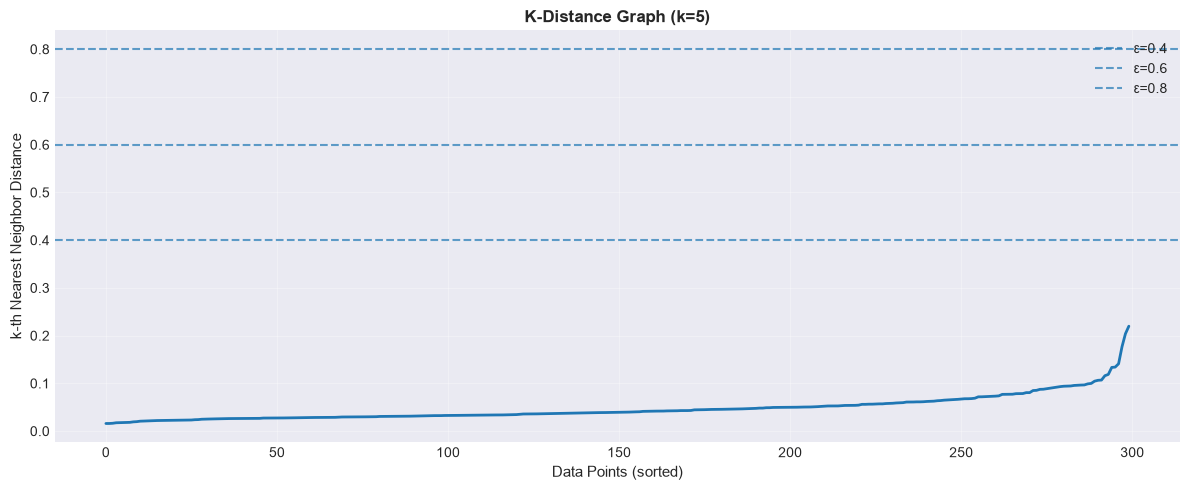

K-distance graph computed. Possible ε values around the 'elbow' at distance ~0.08


In [2]:
# Generate test data
X, _ = make_blobs(n_samples=300, centers=4, n_features=2, cluster_std=0.5, random_state=42)
X = StandardScaler().fit_transform(X)

# Compute k-distance graph
k = 5  # minpts
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort distances
distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(distances, linewidth=2)
ax.set_ylabel('k-th Nearest Neighbor Distance', fontsize=11)
ax.set_xlabel('Data Points (sorted)', fontsize=11)
ax.set_title(f'K-Distance Graph (k={k})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Mark possible epsilon values
eps_candidates = [0.4, 0.6, 0.8]
for eps in eps_candidates:
    ax.axhline(y=eps, linestyle='--', linewidth=1.5, alpha=0.7, label=f'ε={eps}')

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"K-distance graph computed. Possible ε values around the 'elbow' at distance ~{distances[int(len(distances)*0.9)]:.2f}")

<a name="epsilon"></a>
## Parameter Selection on Real Data

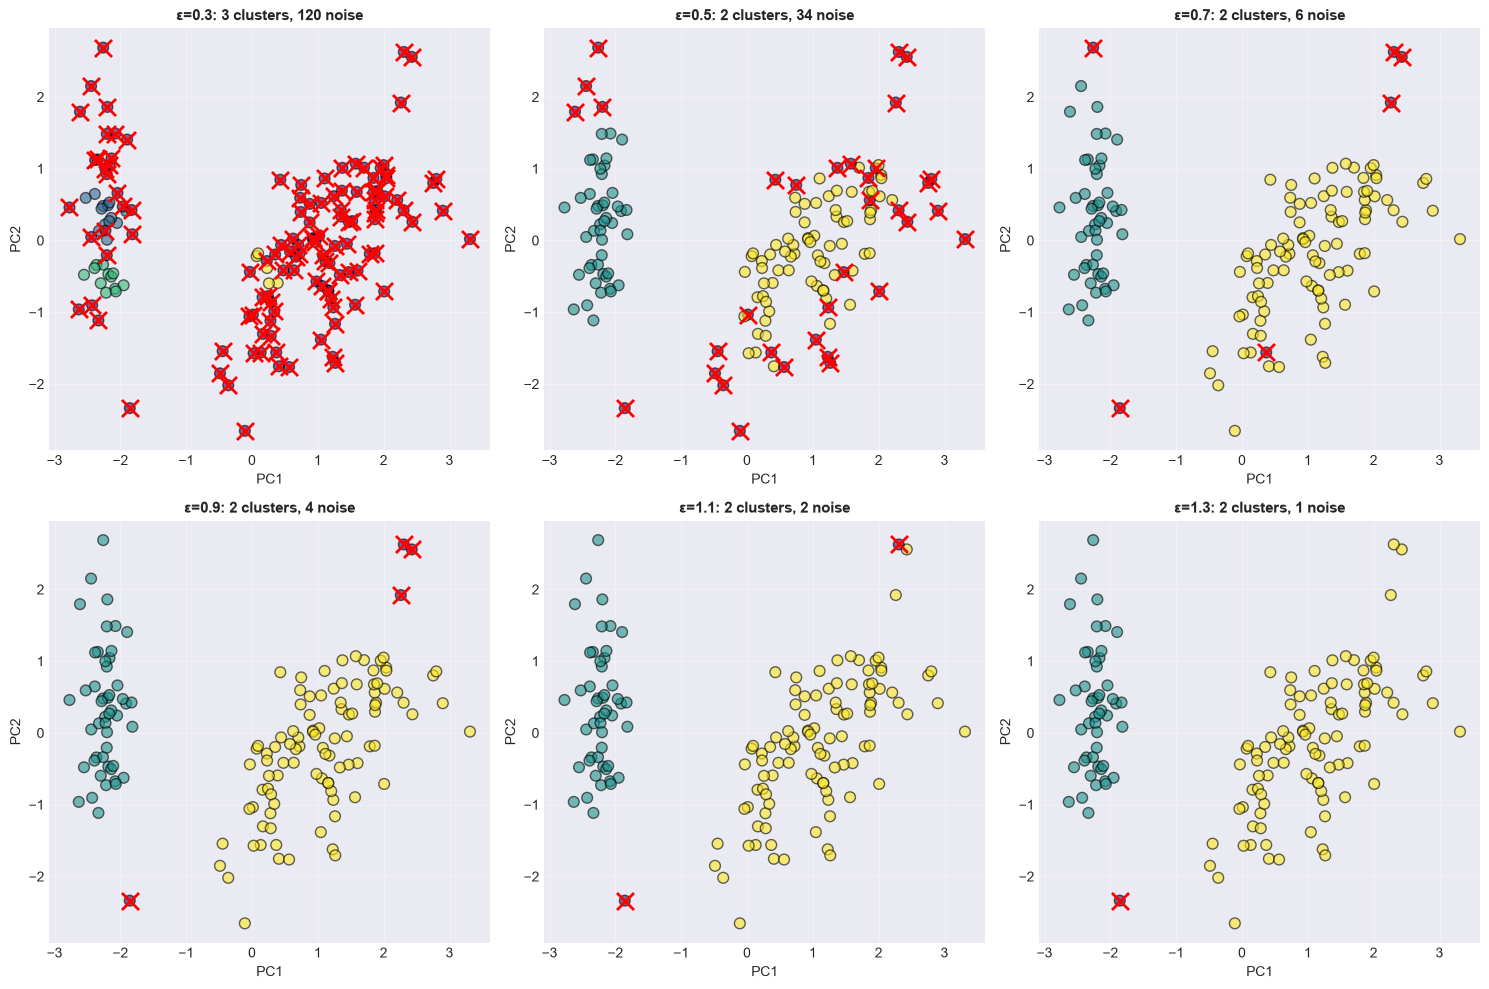

💡 Notice: small ε creates many noise points; large ε merges clusters


In [3]:
# Try different epsilon values
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

for idx, (ax, eps) in enumerate(zip(axes.flat, eps_values)):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_iris)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=60, alpha=0.6, edgecolors='k')
    noise_mask = labels == -1
    ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], marker='x', s=150, c='red', linewidth=2)
    
    ax.set_title(f'ε={eps}: {n_clusters} clusters, {n_noise} noise', fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Notice: small ε creates many noise points; large ε merges clusters")

<a name="hdbscan"></a>
## HDBSCAN: Hierarchical DBSCAN

HDBSCAN addresses DBSCAN's main weakness: **parameter sensitivity**.

Key idea: Build a hierarchy of clusterings for all ε values, then extract the most stable clustering automatically.

Advantages:
- **No ε selection** — automatic
- **Variable-density clusters** — finds clusters of different densities
- **Probabilistic** — each point has a cluster probability

In [4]:
# HDBSCAN requires the hdbscan package
# Install: pip install hdbscan

try:
    import hdbscan
    
    # Apply HDBSCAN
    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3)
    labels_hdbscan = clusterer.fit_predict(X_iris)
    
    # Get cluster probabilities
    probabilities = clusterer.probabilities_
    
    n_clusters = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
    n_noise = list(labels_hdbscan).count(-1)
    
    print(f"HDBSCAN Results:")
    print(f"  Clusters: {n_clusters}")
    print(f"  Noise points: {n_noise}")
    print(f"  Mean cluster probability: {probabilities.mean():.3f}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hdbscan, cmap='viridis', s=100, alpha=0.6, edgecolors='k')
    noise_mask = labels_hdbscan == -1
    ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], marker='x', s=200, c='red', linewidth=3, label='Noise')
    
    ax.set_title('HDBSCAN: Automatic clustering without epsilon selection', fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️  hdbscan not installed. Install with: pip install hdbscan")
    print("For now, we'll show DBSCAN results instead.")

⚠️  hdbscan not installed. Install with: pip install hdbscan
For now, we'll show DBSCAN results instead.


<a name="comparison"></a>
## Comparison: K-Means vs. Hierarchical vs. DBSCAN

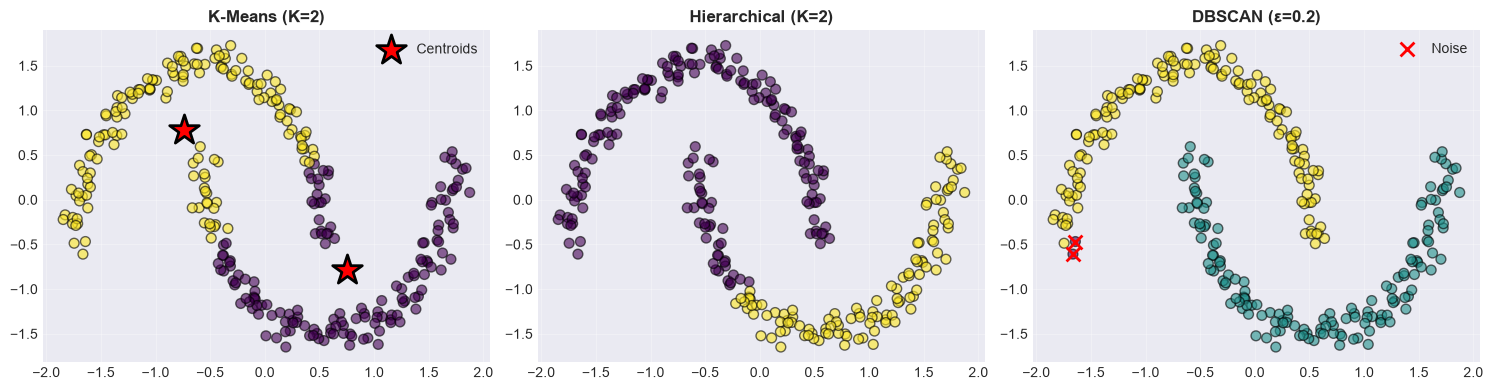

💡 DBSCAN finds the moon shape; K-Means draws a line through them


In [5]:
# Test all three on non-convex data
moons, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
moons = StandardScaler().fit_transform(moons)

# K-Means
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(moons)

# Hierarchical
hier = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hier = hier.fit_predict(moons)

# DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(moons)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# K-Means
ax = axes[0]
ax.scatter(moons[:, 0], moons[:, 1], c=labels_km, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='*', s=500, edgecolors='black', linewidth=2, label='Centroids')
ax.set_title('K-Means (K=2)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Hierarchical
ax = axes[1]
ax.scatter(moons[:, 0], moons[:, 1], c=labels_hier, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
ax.set_title('Hierarchical (K=2)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# DBSCAN
ax = axes[2]
ax.scatter(moons[:, 0], moons[:, 1], c=labels_dbscan, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
noise = labels_dbscan == -1
ax.scatter(moons[noise, 0], moons[noise, 1], marker='x', s=100, c='red', linewidth=2, label='Noise')
ax.set_title(f'DBSCAN (ε=0.2)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("💡 DBSCAN finds the moon shape; K-Means draws a line through them")

<a name="when"></a>
## Decision Guide: When to Use Each Method

| Scenario | Method | Why |
|----------|--------|-----|
| **Large dataset (>10k)** | K-Means | Speed O(n) |
| **Need K upfront** | K-Means | Requirement |
| **Spherical clusters** | K-Means | Optimal |
| **Unknown structure** | Hierarchical | Dendrograms reveal |
| **Arbitrary shapes** | DBSCAN / HDBSCAN | Design feature |
| **Noise outliers critical** | DBSCAN / HDBSCAN | Explicit noise |
| **Variable density** | HDBSCAN | Automatic |
| **Parameter-sensitive task** | HDBSCAN | Auto selection |
| **Interpretability essential** | Hierarchical | Dendrograms |
| **Speed critical** | K-Means | O(n log n) or O(n) |

### Practical Workflow

1. **Start with K-Means** — fast baseline
2. **If clusters are non-convex** → try Hierarchical or DBSCAN
3. **If outliers important** → try DBSCAN or HDBSCAN
4. **If parameter selection hard** → try HDBSCAN (auto ε)
5. **Compare results** with silhouette or Davies-Bouldin scores

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **K-distance graphs** are the gold standard for choosing ε
2. **HDBSCAN** eliminates the need for manual ε selection
3. **DBSCAN excels** at finding arbitrary shapes and noise
4. **Trade-offs**:
   - K-Means: Fast, simple, but spherical assumption
   - Hierarchical: Interpretable, but slow
   - DBSCAN: Flexible, but parameter-sensitive
   - HDBSCAN: Best of DBSCAN without the parameters

### You Now Know All Three Major Clustering Paradigms

✅ **K-Means** (Lesson 1): Partitioning, distance-based
✅ **Hierarchical** (Lesson 2): Agglomerative, dendrograms
✅ **DBSCAN** (Lesson 3): Density-based, arbitrary shapes

Next lessons build on these foundations:
- **Lesson 4**: Gaussian Mixture Models (soft, probabilistic clustering)
- **Lesson 5**: PCA (dimensionality reduction)
- **Lesson 6+**: Advanced unsupervised learning

You're now ready to solve real-world clustering problems! 🎓